# Grad-CAM Demo: Pretrained ResNet50 (ImageNet) na obrazach BUSI

Demo pipelineu - analiza co model "widzi"

## Instalacja zależności (opcjonalna)

Poniższa komórka instaluje bibliotekę `pytorch-grad-cam`. Uruchom ją tylko jeśli biblioteka nie jest jeszcze zainstalowana.

In [ ]:
# [OPCJONALNE] Odkomentuj i uruchom, jeśli grad-cam nie jest zainstalowany
# !pip install grad-cam

## Import bibliotek

In [1]:
import os
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.11.0+cu130
Device: cuda


## Konfiguracja

In [ ]:
# Konfiguracja
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
OUTPUT_DIR = 'gradcam_outputs/option_A'
NUM_SAMPLES_PER_CLASS = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR}")

Device: cuda
Output directory: gradcam_outputs/option_A


## Przygotowanie danych

Automatyczne wykrywanie folderu z danymi BUSI.

In [3]:
def find_dataset_root():
    """Automatycznie znajduje folder z danymi klasyfikacyjnymi BUSI."""
    base = Path('.')
    candidates = [
        base / 'Dataset_BUSI_noisy',
        base / 'Dataset_BUSI_with_GT',
    ]
    # Sprawdź bezpośrednie kandydatury
    for candidate in candidates:
        if candidate.exists():
            subdirs = {d.name for d in candidate.iterdir() if d.is_dir()}
            if {'benign', 'malignant', 'normal'}.issubset(subdirs):
                return candidate
    # Szukaj dowolnego folderu z odpowiednimi podfolderami
    for folder in base.rglob('*'):
        if folder.is_dir():
            subdirs = {d.name for d in folder.iterdir() if d.is_dir()}
            if {'benign', 'malignant', 'normal'}.issubset(subdirs):
                return folder
    raise FileNotFoundError(
        "Nie znaleziono folderu z danymi BUSI.\n"
        "Oczekiwany folder z podfolderami: benign/, malignant/, normal/\n"
        "Ustaw ścieżkę ręcznie: DATASET_ROOT = Path('ścieżka/do/danych')"
    )


DATASET_ROOT = find_dataset_root()
CLASSES = ['benign', 'malignant', 'normal']
print(f"Dataset root: {DATASET_ROOT.resolve()}")
for cls in CLASSES:
    cls_dir = DATASET_ROOT / cls
    n_files = len([f for f in cls_dir.iterdir() if f.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}])
    print(f"  {cls}: {n_files} obrazów")

Dataset root: /home/o0i3z3/university/dl/p2/neural_networks_project/Dataset_BUSI_noisy
  benign: 294 obrazów
  malignant: 420 obrazów
  normal: 266 obrazów


## Funkcje pomocnicze

In [4]:
def load_image_for_visualization(img_path, img_size=IMG_SIZE):
    """Wczytuje obraz i zwraca tensor do modelu oraz numpy array do wizualizacji."""
    img = Image.open(img_path).convert('RGB')
    
    # Preprocessing dla modelu
    preprocess = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    input_tensor = preprocess(img).unsqueeze(0)  # [1, 3, H, W]
    
    # Obraz do wizualizacji (0-1 float RGB)
    vis_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    rgb_img = vis_transform(img).permute(1, 2, 0).numpy()  # [H, W, 3]
    
    return input_tensor, rgb_img


def denormalize_tensor(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Odwraca normalizację tensora do wizualizacji."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def get_sample_images(dataset_root, classes, num_per_class=2):
    """Pobiera próbkowe obrazy z każdej klasy (bez masek)."""
    samples = {}
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp'}
    for cls in classes:
        cls_dir = dataset_root / cls
        all_images = sorted([
            f for f in cls_dir.iterdir()
            if f.suffix.lower() in image_extensions
            and '_mask' not in f.stem
            and '__noise_' not in f.stem  # Preferujemy oryginały
        ])
        if len(all_images) < num_per_class:
            # Jeśli za mało oryginalnych, weź też noisy
            all_images = sorted([
                f for f in cls_dir.iterdir()
                if f.suffix.lower() in image_extensions
                and '_mask' not in f.stem
            ])
        samples[cls] = all_images[:num_per_class]
    return samples


def generate_gradcam(model, target_layers, input_tensor, target_class=None):
    """Generuje mapę Grad-CAM dla danego obrazu i klasy."""
    targets = [ClassifierOutputTarget(target_class)] if target_class is not None else None
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    return grayscale_cam[0]  # [H, W]


def save_visualization(rgb_img, cam_mask, title, save_path):
    """Zapisuje wizualizację: oryginalny obraz, Grad-CAM, overlay."""
    overlay = show_cam_on_image(rgb_img, cam_mask, use_rgb=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(rgb_img)
    axes[0].set_title('Oryginalny obraz')
    axes[0].axis('off')
    
    axes[1].imshow(cam_mask, cmap='jet')
    axes[1].set_title('Grad-CAM heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title('Grad-CAM overlay')
    axes[2].axis('off')
    
    fig.suptitle(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Zapisano: {save_path}")

## Model: ResNet50 (pretrained ImageNet)

Wczytanie modelu z wagami IMAGENET1K_V2. Target layer: `model.layer4[-1]`.

In [5]:
# Wczytanie modelu
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model = model.to(DEVICE)
model.eval()

# Target layer dla Grad-CAM
target_layers = [model.layer4[-1]]

# Etykiety ImageNet (top-level)
imagenet_categories = ResNet50_Weights.IMAGENET1K_V2.meta['categories']

print(f"Model: ResNet50 (IMAGENET1K_V2)")
print(f"Target layer: model.layer4[-1] ({type(model.layer4[-1]).__name__})")
print(f"Liczba klas ImageNet: {len(imagenet_categories)}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/o0i3z3/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 23.0MB/s]


Model: ResNet50 (IMAGENET1K_V2)
Target layer: model.layer4[-1] (Bottleneck)
Liczba klas ImageNet: 1000


## Grad-CAM: Generowanie wizualizacji

Dla każdego przykładowego obrazu BUSI:
1. Wykonujemy predykcję ImageNet (model nie zna klas BUSI).
2. Generujemy Grad-CAM dla przewidzianej klasy ImageNet.
3. Wyświetlamy i zapisujemy wynik.

In [6]:
# Pobranie próbkowych obrazów
samples = get_sample_images(DATASET_ROOT, CLASSES, num_per_class=NUM_SAMPLES_PER_CLASS)

print("Próbkowe obrazy:")
for cls, paths in samples.items():
    print(f"  {cls}: {[p.name for p in paths]}")

Próbkowe obrazy:
  benign: ['benign (1).png', 'benign (10).png']
  malignant: ['malignant (1).png', 'malignant (10).png']
  normal: ['normal (1).png', 'normal (10).png']



Przetwarzanie: benign/benign (1).png
  Predykcja ImageNet: 'tiger shark' (prob: 0.0653)


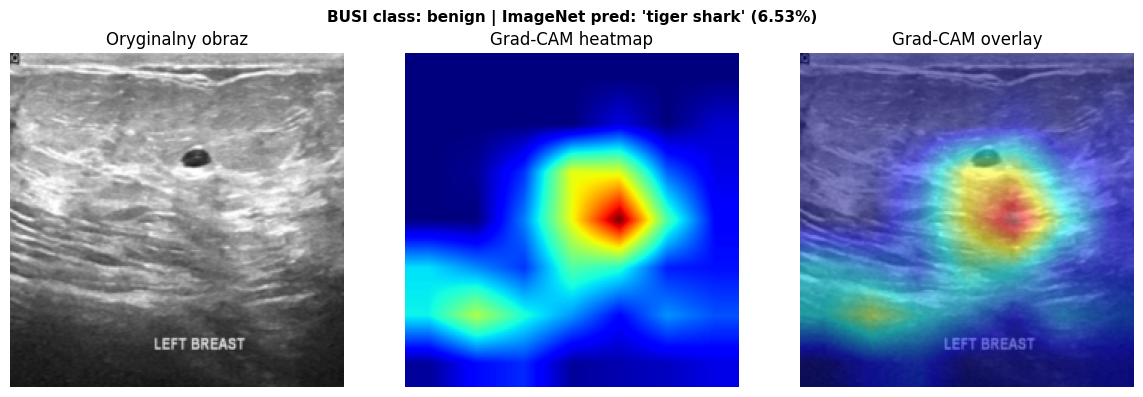

  Zapisano: gradcam_outputs/option_A/gradcam_benign_benign (1).png

Przetwarzanie: benign/benign (10).png
  Predykcja ImageNet: 'puffer' (prob: 0.0356)


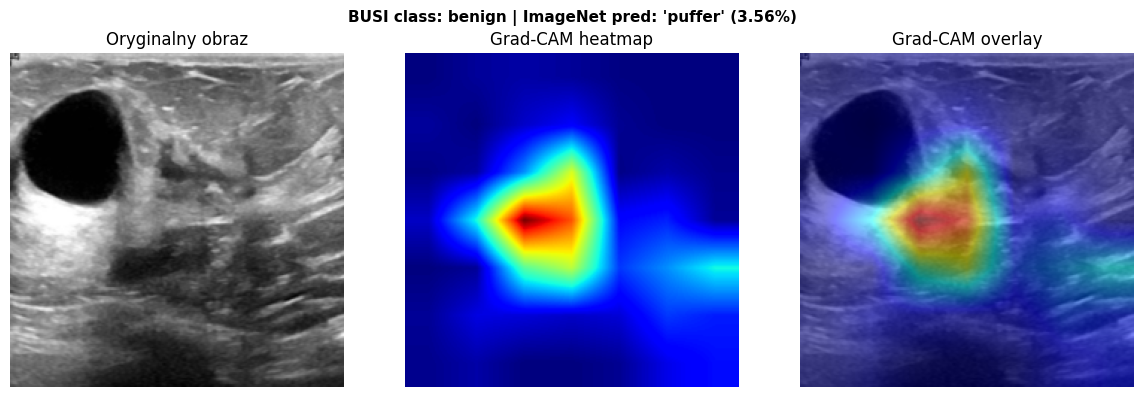

  Zapisano: gradcam_outputs/option_A/gradcam_benign_benign (10).png

Przetwarzanie: malignant/malignant (1).png
  Predykcja ImageNet: 'airship' (prob: 0.0392)


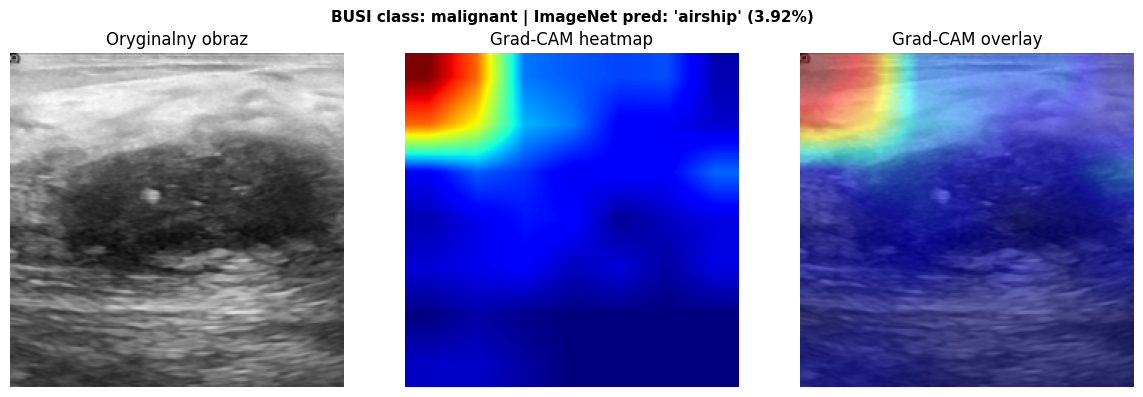

  Zapisano: gradcam_outputs/option_A/gradcam_malignant_malignant (1).png

Przetwarzanie: malignant/malignant (10).png
  Predykcja ImageNet: 'great white shark' (prob: 0.0625)


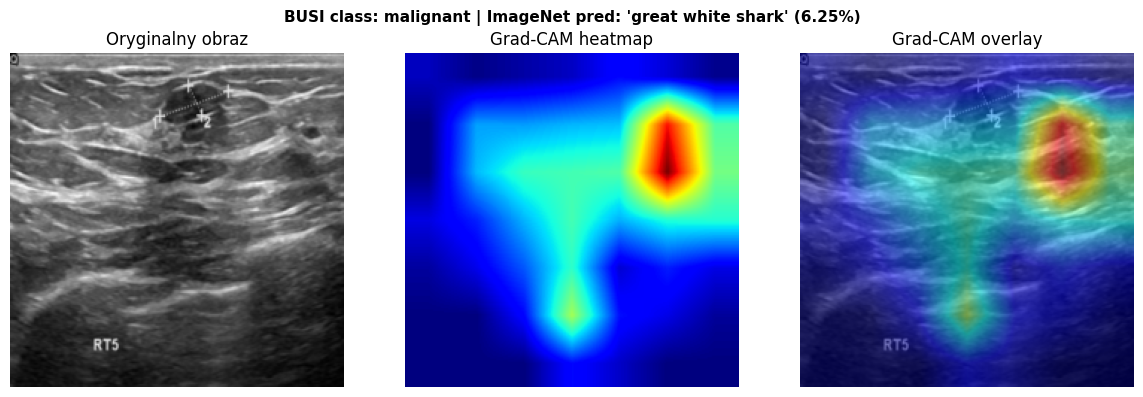

  Zapisano: gradcam_outputs/option_A/gradcam_malignant_malignant (10).png

Przetwarzanie: normal/normal (1).png
  Predykcja ImageNet: 'grey whale' (prob: 0.0620)


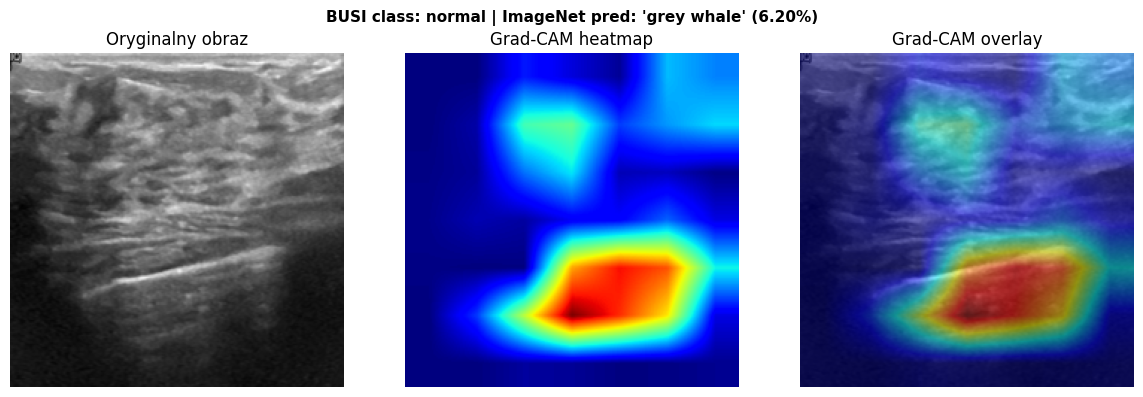

  Zapisano: gradcam_outputs/option_A/gradcam_normal_normal (1).png

Przetwarzanie: normal/normal (10).png
  Predykcja ImageNet: 'trilobite' (prob: 0.0432)


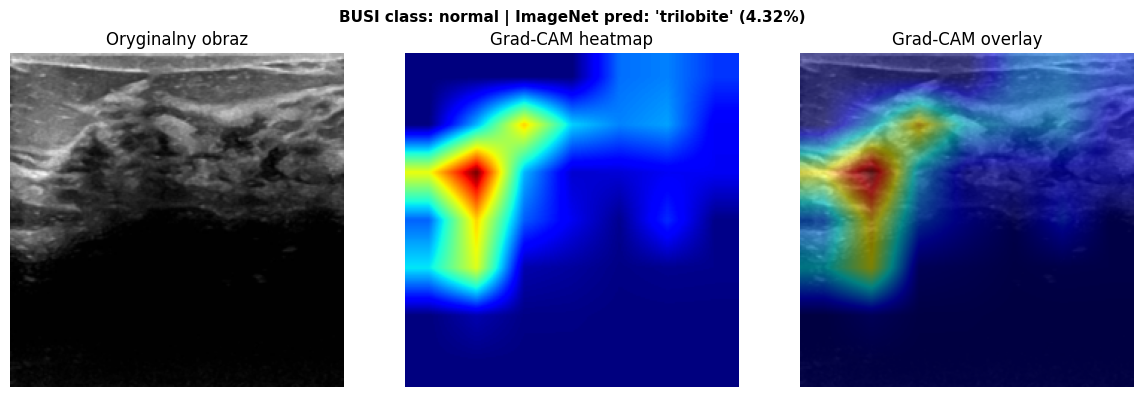

  Zapisano: gradcam_outputs/option_A/gradcam_normal_normal (10).png


In [7]:
# Generowanie Grad-CAM dla wszystkich próbek
results = []

for cls in CLASSES:
    for img_path in samples[cls]:
        print(f"\nPrzetwarzanie: {cls}/{img_path.name}")
        
        # Wczytanie obrazu
        input_tensor, rgb_img = load_image_for_visualization(img_path)
        input_tensor = input_tensor.to(DEVICE)
        
        # Predykcja ImageNet
        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.nn.functional.softmax(output[0], dim=0)
            predicted_class_idx = probabilities.argmax().item()
            predicted_prob = probabilities[predicted_class_idx].item()
            predicted_label = imagenet_categories[predicted_class_idx]
        
        print(f"  Predykcja ImageNet: '{predicted_label}' (prob: {predicted_prob:.4f})")
        
        # Grad-CAM
        cam_mask = generate_gradcam(model, target_layers, input_tensor, target_class=predicted_class_idx)
        
        # Wizualizacja i zapis
        title = f"BUSI class: {cls} | ImageNet pred: '{predicted_label}' ({predicted_prob:.2%})"
        save_path = os.path.join(OUTPUT_DIR, f"gradcam_{cls}_{img_path.stem}.png")
        save_visualization(rgb_img, cam_mask, title, save_path)
        
        results.append({
            'busi_class': cls,
            'image': img_path.name,
            'imagenet_prediction': predicted_label,
            'probability': predicted_prob,
        })

## Wyniki: Podsumowanie predykcji

In [8]:
import pandas as pd

results_df = pd.DataFrame(results)
print("\nPodsumowanie predykcji ImageNet na obrazach BUSI:")
print(results_df.to_string(index=False))

print(f"\nWszystkie wizualizacje zapisane w: {OUTPUT_DIR}/")
print(f"Liczba wygenerowanych map Grad-CAM: {len(results)}")


Podsumowanie predykcji ImageNet na obrazach BUSI:
busi_class              image imagenet_prediction  probability
    benign     benign (1).png         tiger shark     0.065313
    benign    benign (10).png              puffer     0.035629
 malignant  malignant (1).png             airship     0.039216
 malignant malignant (10).png   great white shark     0.062546
    normal     normal (1).png          grey whale     0.061990
    normal    normal (10).png           trilobite     0.043191

Wszystkie wizualizacje zapisane w: gradcam_outputs/option_A/
Liczba wygenerowanych map Grad-CAM: 6
